# Ecuaciones diferenciales

## Ecuaciones diferenciales de primer orden con una variable

Resolveremos ecuaciones diferenciales de primer orden con una variable que no son resueltas fácilmente.

E.g.

$$\frac{dx}{dt}=\frac{2x}{t}+\frac{3x^2}{t^3}$$

### Método de Euler

Supongamos que tenemos
$$\frac{dx}{dt}=f(x,t)$$

Con una condición inicial en x y t. Expandiendo $x(t+h)$ en serie de Taylor:
$$
x(t+h)=x(t)+h\frac{dx}{dt}+\frac{1}{2}h^2\frac{d^2x}{dt^2}+\cdots\\
       =x(t)+hf(x,t)+O(h^{2})
$$

A programar:
            $$
            x(t+h)=x(t)+hf(x,t)
            $$
 

Ejercicio: 

$$\frac{dx}{dt}=-x^3+\sin(t)$$

Haz un programa que grafique t en el intervalo [0,10] con 1000 pasos

Text(0, 0.5, 'x(t)')

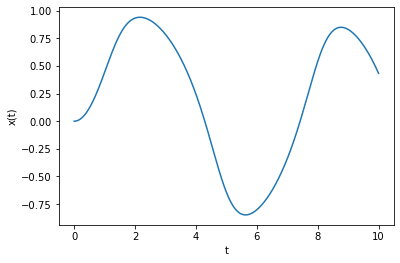

In [2]:
import matplotlib.pyplot as plt
from numpy import sin,linspace

def euler(n,t0,x0,f,t): #n es la cantidad de pasos, x0 es la condición incial em t0, la función f y el punto dnd queremos evaluar.
    contador=0
    T=[t0]
    X=[x0]
    x=x0
    h=(t-t0)/n
    while contador<n:
        x+=h*f(t0,x)
        X.append(x)
        t0+=h
        T.append(t0)
        contador+=1
        
    return(T,X)

def f(t,x):
    return(-x**3+sin(t))

tp,xp=euler(1000,0,0,f,10)

plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')


Text(0, 0.5, 'x(t)')

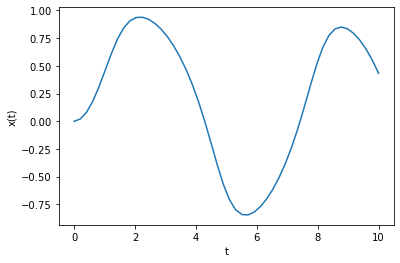

In [3]:
#Aquí aplicamos Euler en cada punto donde evaluamos del intervalo [0,10], es otra forma de gacerlo aunque posiblemente no sea tan eficiente computacionalmente hablando

def euler(n,t0,x0,f,t): #n es la cantidad de pasos, x0 es la condición incial em t0, la función f y el punto dnd queremos evaluar.
    contador=0
    x=x0
    h=(t-t0)/n
    while contador<n:
        x+=h*f(t0,x)
        t0+=h
        contador+=1
    return(x)

tp=linspace(0,10)
xp=euler(1000,0,0,f,tp) #Tomamos como condición inicial x0=0 en t0=0

#print(xp)

plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')
        
        

El error de truncamiento o error local es $h^2$. Cada paso tiene este error. Sin embargo, a lo largo de los 1000 pasos, se obtiene un error acumulado o el error global del método numérico.

El error global se obtiene sumando N-1 veces el error local:
$$
\sum_{k=0}^{N-1} \frac{1}{2}h^2\left[\frac{d^2x}{dt^2} \right]_{t=t_k}=
\frac{1}{2}h\sum_{k=0}^{N-1}h\left[\frac{df}{dt} \right]_{t=t_k}\approx
\frac{h}{2}\int_a^b\frac{df}{dt} dt=\frac{h}{2}\left[f(x(b),b)-f(x(a),a)\right]
$$

Entonces, el error global es proporcional a $h$

## Método de Runge-Kutta de orden 2

Cuidado: Extender la serie de Taylor a un orden superior no hace que se mejore la solución (sólo en algunos casos). Para mejorar usaremos el método de Runge-Kutta de segundo orden, o también conocido como el método del punto medio.

Dessarrollando con serie de Taylor alrededor de $t+\frac{1}{2}h$ para $x(t+h)$:

$$
x(t+h)=x(t+\frac{1}{2}h)+\frac{1}{2}h \left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h}+\frac{1}{8}h^2\left(\frac{d^2x}{dt^2}\right)_{t+\frac{1}{2}h}+O(h^{3})\\
$$

Haciendo lo mismo para $x(t)$:

$$
x(t)=x(t+\frac{1}{2}h)-\frac{1}{2}h \left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h}+\frac{1}{8}h^2\left(\frac{d^2x}{dt^2}\right)_{t+\frac{1}{2}h}+O(h^{3})\\
$$

Restando la segunda expresión de la primera y reacomodando términos:

$$
x(t+h)=x(t)+h\left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h}+O(h^{3})\\
=x(t)+hf(x(t+\frac{1}{2}h),t+\frac{1}{2}h)+O(h^{3})
$$

Un detalle importante, no conocemos en realidad $x(t+\frac{1}{2}h)$! 

Para eso usamos el método de Euler, de esta manera podemos escribir:

$$
k_1=hf(x,t);\\
k_2=hf(x+\frac{1}{2}k_1,t+\frac{1}{2}h);\\
x(t+h)=x(t)+k_2
$$


Ya vimos que $x(t+h)$ tiene terminos de $O(h^{3})$ lo cual es aún mejor que el de Euler ($O(h^{2})$). Pero estamos asumiendo que usar Euler para la estimación original no mete terminos en Runge-Kutta en $x(t+h)$ mayores que $O(h^{3})$.

Si haces una demostración correcta de porque este es el caso y lo expones en video tendras medio punto extra sobre esta tarea. (Hint: demuestra que $k_2$ va como $O(h^{3})$, expandiendo en serie de Taylor $f$ y $x$ alrededor de $t+\frac{1}{2}h$)



In [6]:
#Aqui pon tu metodo de Runge-Kutta de orden 2

def rk2(n,t0,x0,f,t):
    contador=0
    h=(t-t0)/n
    T=[t0]
    X=[x0]
    while contador<n:
        k1=h*f(t0,x0)
        k2=h*f(t0+0.5*h,x0+0.5*k1)
        x0+=k2
        X.append(x0)
        t0+=h
        T.append(t0)
        contador+=1
    return(T,X)
    

Text(0, 0.5, 'x(t)')

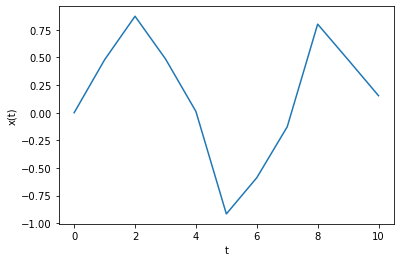

In [7]:
#Resolviendo la ecuación con 10 pasos, n=10
tp,xp=rk2(10,0,0,f,10)

plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, 'x(t)')

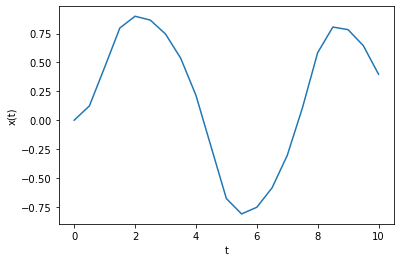

In [8]:
#Con 20 pasos
tp,xp=rk2(20,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, 'x(t)')

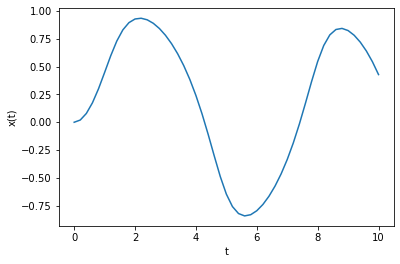

In [9]:
#Con 50 pasos
tp,xp=rk2(50,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, 'x(t)')

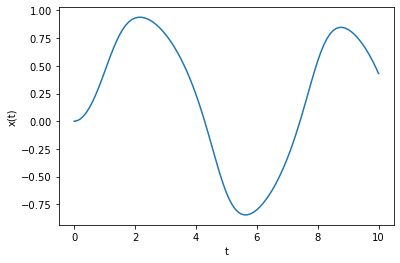

In [10]:
#Con 100 pasos
tp,xp=rk2(100,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Vemos que entre mayor es el número de pasos, más se acerca a la gráfica esperada. 

Al compararlo con el método de Euler, vemos que para una menor cantidad de pasos, obtenemos una mejor aproximación con el método de Runge-Kutta, lo cual se aprecia en las gráficas pues, con sólo 100 pasos, obtuvimos una gráfica que, para obtener una similar con Euler, se necesitaron 1000 pasos. Esto nos indica que el método de Runge-Kutta converge más rápido que el de Euler.



### Método de Runge-Kutta de orden 4.

$$
k_1=hf(x,t)
$$

$$
k_2=hf(x+0.5k_1,t+0.5h)
$$

$$
k_3=hf(x+0.5k_2,t+0.5h)
$$

$$
k_4=hf(x+k_3,t+h)
$$

$$
x(t+h)=x(t)+\frac{(k_1+2k_2+2k_3+k_4)}{6.}
$$

Si haces un vídeo exponiendo correctamente la deducción de Runge-Kutta de órden 4 tienes medio punto extra sobre esta tarea.

Errores en las deducciones y en las implementaciones pueden llevar a resultados que parecen sensatos pero en realidad son erroneos!

Describe un criterio para averiguar rápidamente si el código que resuelve una ecuación diferencial esta mal:

### PON AQUI TU RESPUESTA

Podríamos verificar con una ecuación diferencial fácil de resolver analíticamente checando los valores de la función solución vs los obtenidos con el código. 

Por otro lado, podríamos analizar y comparar el comportamiento cualitativo de las soluciones, el cual podemos conocer sin saber necesariamente la solución a la ecuación, tal como los puntos de equilibrio y su estabilidad.

In [15]:
def rk4(n,t0,x0,f,t):
    contador=0
    h=(t-t0)/n
    T=[t0]
    X=[x0]
    while contador<n:
        k1=h*f(t0,x0)
        k2=h*f(t0+0.5*h,x0+0.5*k1)
        k3=h*f(t0+0.5*h,x0+0.5*k2)
        k4=h*f(t0+h,x0+k3)
        x0+=(k1+2*k2+2*k3+k4)/6
        X.append(x0)
        t0+=h
        T.append(t0)
        contador+=1
    return(T,X)


Text(0, 0.5, 'x(t)')

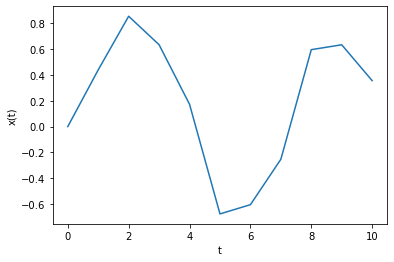

In [12]:
#Con 10 pasos
tp,xp=rk4(10,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, 'x(t)')

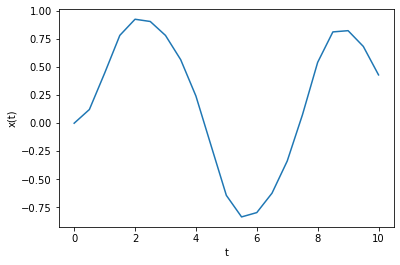

In [13]:
#Con 20 pasos
tp,xp=rk4(20,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, 'x(t)')

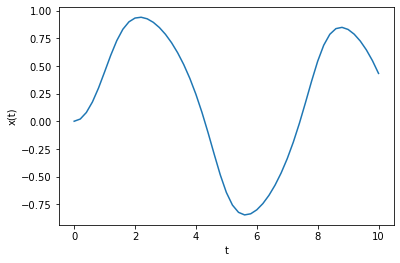

In [17]:
#Con 50 pasos
tp,xp=rk4(50,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, 'x(t)')

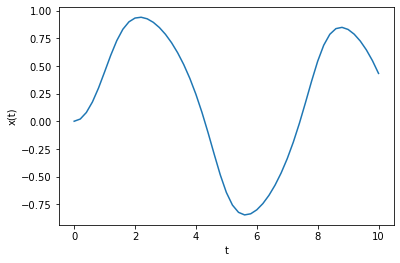

In [19]:
#Con 100 pasos
tp,xp=rk4(50,0,0,f,10)
    
plt.plot(tp,xp)
plt.xlabel('t')
plt.ylabel('x(t)')

En este caso, vemos que la convergencia es aún más rápida que con el método de Runge-Kutta de órden 2, pues con una menor cantidad de pasos, se llega a una mejor aproximación. Lo cual lo podemos ver, por ejemplo, comparando las gráficas para 10 pasos, en las cuales, para Runge-Kutta de órden 2, se observa una mayor desviación de la gráfica esperada a compraración de Runge-Kutta de órden 4.